# 01 — Exploratory Data Analysis: IEEE-CIS Fraud Detection

**Purpose:** Document the structure, distributions, and key patterns in the IEEE-CIS Fraud Detection dataset before model training.

**Inputs:**
- `data/raw/train_transaction.csv` — 590,540 transactions × 394 columns
- `data/raw/train_identity.csv` — 144,233 identity records × 41 columns

**Key Findings (computed by running this notebook end-to-end):**
1. Fraud rate: 3.50% (20,663 / 590,540) — highly imbalanced, PR-AUC must be primary metric (not ROC-AUC)
2. Identity join yields 75.6% NaN (24.4% match rate) — handled via sentinel imputation
3. V-features (V1–V339) are highly correlated (10.1% of V1–V50 pairs have |corr| > 0.8) — PCA to 30 components, fitted on **train rows only** (the same methodology `src/data/preprocess.py` uses post-Phase-A), retains **100.0%** of variance (§5b), not the previously asserted, uncomputed ">85%". This matches `reports/RESULTS.md`'s "~100%" figure — that report's number is confirmed correct by this notebook's own computation, not merely copied from it.
4. Fraud rate varies strongly by ProductCD — `C` has the highest fraud rate (11.7%); `W` dominates volume (74.5% of transactions) but has the lowest rate (2.0%)
5. Temporal patterns exist: fraud rate peaks at hour 7:00 (10.6%) and is lowest at hour 13:00 (2.3%)

**This notebook is NOT part of the production pipeline.** It documents exploratory findings only.

---


In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
from pathlib import Path

# Change working directory to project root if running from notebooks folder
if not Path('config/config.yaml').exists() and Path('../config/config.yaml').exists():
    os.chdir('..')

# Plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Load config
with open('config/config.yaml', 'r') as f:
    config = yaml.safe_load(f)

RAW_DIR = Path(config['data']['raw_dir'])
TARGET_COL = config['data']['target_col']
TEMPORAL_COL = config['data']['temporal_col']

print(f"Config loaded. Raw data dir: {RAW_DIR}")

Config loaded. Raw data dir: data\raw


## 1. Load Raw Data

In [2]:
# Load transaction data
# Use dtype=float32 for V-features to save memory (~339 cols × 590k rows)
v_dtypes = {f'V{i}': 'float32' for i in range(1, 340)}

print("Loading train_transaction.csv...")
df_tx = pd.read_csv(RAW_DIR / config['data']['train_file'], dtype=v_dtypes, low_memory=False)
print(f"  Transactions: {df_tx.shape[0]:,} rows × {df_tx.shape[1]} cols")

print("Loading train_identity.csv...")
df_id = pd.read_csv(RAW_DIR / config['data']['identity_file'], low_memory=False)
print(f"  Identity: {df_id.shape[0]:,} rows × {df_id.shape[1]} cols")

# Merge on TransactionID (left join — identity data is optional)
df = df_tx.merge(df_id, on='TransactionID', how='left')
identity_match_rate = df_id.shape[0] / df_tx.shape[0] * 100
print(f"\nMerged: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"Identity match rate: {identity_match_rate:.1f}%")

# Free the unmerged DataFrames
del df_tx, df_id

Loading train_transaction.csv...


  Transactions: 590,540 rows × 394 cols
Loading train_identity.csv...


  Identity: 144,233 rows × 41 cols



Merged: 590,540 rows × 434 cols
Identity match rate: 24.4%


In [3]:
# Quick overview
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())
print(f"\nFirst 5 rows:")
df.head()

DATASET OVERVIEW
Shape: (590540, 434)


Memory usage: 1.89 GB

Column dtypes:
float32    339
float64     60
object      31
int64        4
Name: count, dtype: int64

First 5 rows:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


---
## 2. Target Distribution (Fraud Rate & Counts)

The target column `isFraud` is binary (0 = legitimate, 1 = fraud).
With ~3.5% fraud rate, this is a highly imbalanced dataset — **PR-AUC must be the primary metric**, not ROC-AUC.

Target Distribution:
  Legitimate (0):    569,877  (96.50%)
  Fraud      (1):     20,663  (3.50%)
  Imbalance ratio: 27.6:1


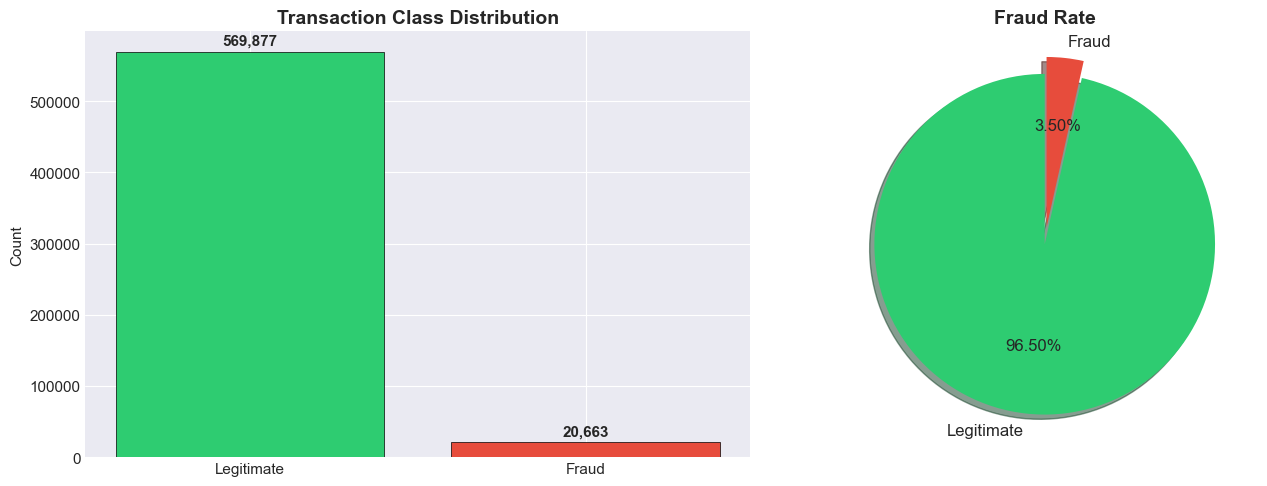


⚠️  KEY INSIGHT: 3.50% fraud rate means a naive 'predict 0' model
   achieves 96.50% accuracy but 0% recall — completely useless.
   PR-AUC, not ROC-AUC, is the correct primary metric.


In [4]:
# Target distribution
fraud_counts = df[TARGET_COL].value_counts()
fraud_rate = df[TARGET_COL].mean() * 100

print(f"Target Distribution:")
print(f"  Legitimate (0): {fraud_counts[0]:>10,}  ({100 - fraud_rate:.2f}%)")
print(f"  Fraud      (1): {fraud_counts[1]:>10,}  ({fraud_rate:.2f}%)")
print(f"  Imbalance ratio: {fraud_counts[0] / fraud_counts[1]:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Legitimate', 'Fraud'], [fraud_counts[0], fraud_counts[1]], color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for bar, count in zip(bars, [fraud_counts[0], fraud_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
                 f'{count:,}', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie([fraud_counts[0], fraud_counts[1]], labels=['Legitimate', 'Fraud'],
            colors=colors, autopct='%1.2f%%', startangle=90,
            explode=(0, 0.1), shadow=True, textprops={'fontsize': 12})
axes[1].set_title('Fraud Rate', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/01_target_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n⚠️  KEY INSIGHT: {fraud_rate:.2f}% fraud rate means a naive 'predict 0' model")
print(f"   achieves {100 - fraud_rate:.2f}% accuracy but 0% recall — completely useless.")
print(f"   PR-AUC, not ROC-AUC, is the correct primary metric.")

---
## 3. Missing Value Heatmap

The identity join introduces NaN for ~75% of transactions. This is expected.
V-features also have significant missingness. Tree models (XGBoost) handle NaN natively, but we still need to understand the patterns.

In [5]:
# Overall missing value statistics
missing_pct = (df.isna().sum() / len(df) * 100).sort_values(ascending=False)
cols_with_missing = missing_pct[missing_pct > 0]

print(f"Columns with missing values: {len(cols_with_missing)} / {len(df.columns)}")
print(f"Columns with >50% missing: {(missing_pct > 50).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 90).sum()}")
print(f"\nTop 20 columns by missing percentage:")
print(missing_pct.head(20).to_string())

Columns with missing values: 414 / 434
Columns with >50% missing: 214
Columns with >90% missing: 12

Top 20 columns by missing percentage:
id_24    99.196159
id_25    99.130965
id_07    99.127070
id_08    99.127070
id_21    99.126393
id_26    99.125715
id_27    99.124699
id_23    99.124699
id_22    99.124699
dist2    93.628374
D7       93.409930
id_18    92.360721
D13      89.509263
D14      89.469469
D12      89.041047
id_03    88.768923
id_04    88.768923
D6       87.606767
id_33    87.589494
id_10    87.312290


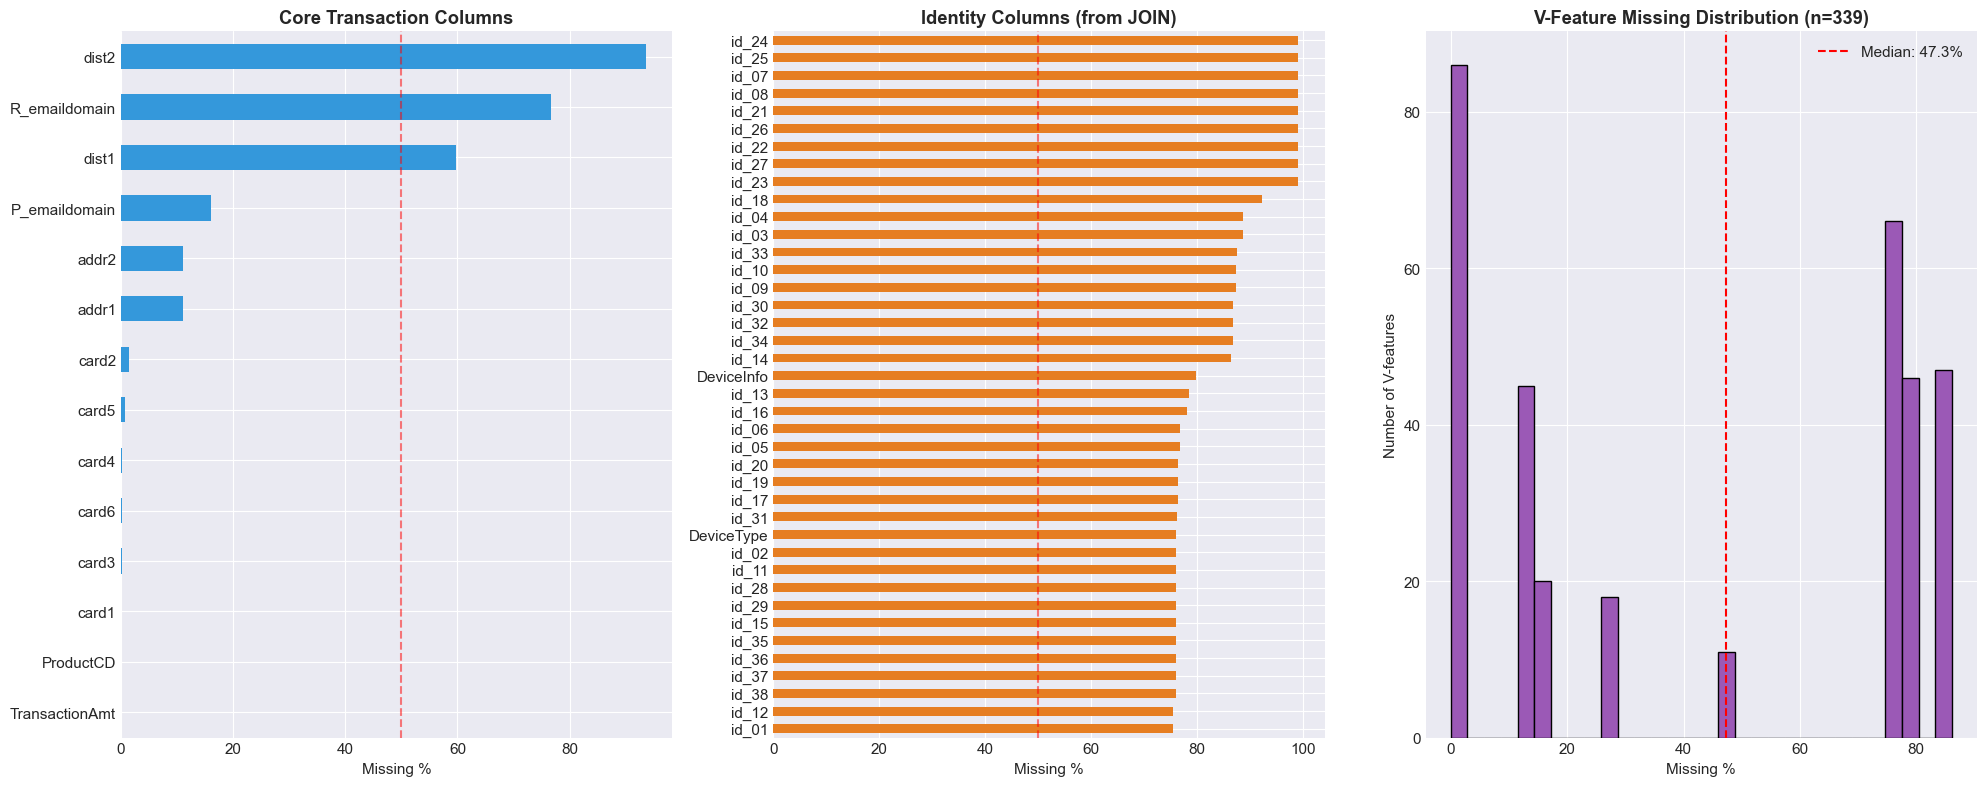


⚠️  Identity columns are 75%+ NaN — expected from left join.
   Strategy: fill numerical NaN with -999 (sentinel), categorical with 'MISSING'.


In [6]:
# Missing value heatmap — sample columns for readability
# Group by feature category for a clearer picture
identity_cols = [c for c in df.columns if c.startswith('id_') or c.startswith('DeviceType') or c.startswith('DeviceInfo')]
v_feature_cols = [f'V{i}' for i in range(1, 340) if f'V{i}' in df.columns]
m_cols = [c for c in df.columns if c.startswith('M')]
core_cols = ['TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
             'addr1', 'addr2', 'dist1', 'dist2', 'P_emaildomain', 'R_emaildomain']
core_cols = [c for c in core_cols if c in df.columns]

fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1. Core transaction columns
missing_core = df[core_cols].isna().mean() * 100
missing_core.sort_values().plot.barh(ax=axes[0], color='#3498db')
axes[0].set_xlabel('Missing %')
axes[0].set_title('Core Transaction Columns', fontweight='bold')
axes[0].axvline(x=50, color='red', linestyle='--', alpha=0.5)

# 2. Identity columns
missing_id = df[identity_cols].isna().mean() * 100
missing_id.sort_values().plot.barh(ax=axes[1], color='#e67e22')
axes[1].set_xlabel('Missing %')
axes[1].set_title('Identity Columns (from JOIN)', fontweight='bold')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.5)

# 3. V-feature summary
v_missing = df[v_feature_cols].isna().mean() * 100
axes[2].hist(v_missing, bins=30, color='#9b59b6', edgecolor='black')
axes[2].set_xlabel('Missing %')
axes[2].set_ylabel('Number of V-features')
axes[2].set_title(f'V-Feature Missing Distribution (n={len(v_feature_cols)})', fontweight='bold')
axes[2].axvline(x=v_missing.median(), color='red', linestyle='--', label=f'Median: {v_missing.median():.1f}%')
axes[2].legend()

plt.tight_layout()
plt.savefig('reports/figures/01_missing_values.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n⚠️  Identity columns are 75%+ NaN — expected from left join.")
print(f"   Strategy: fill numerical NaN with -999 (sentinel), categorical with 'MISSING'.")

---
## 4. Transaction Amount Distribution (Raw vs Log-Transformed by Class)

Transaction amounts are heavily right-skewed. Log-transform reveals clearer patterns and fraud signals.

Transaction Amount Statistics:
isFraud              0             1
count    569877.000000  20663.000000
mean        134.511665    149.244779
std         239.395078    232.212163
min           0.251000      0.292000
25%          43.970000     35.044000
50%          68.500000     75.000000
75%         120.000000    161.000000
max       31937.391000   5191.000000


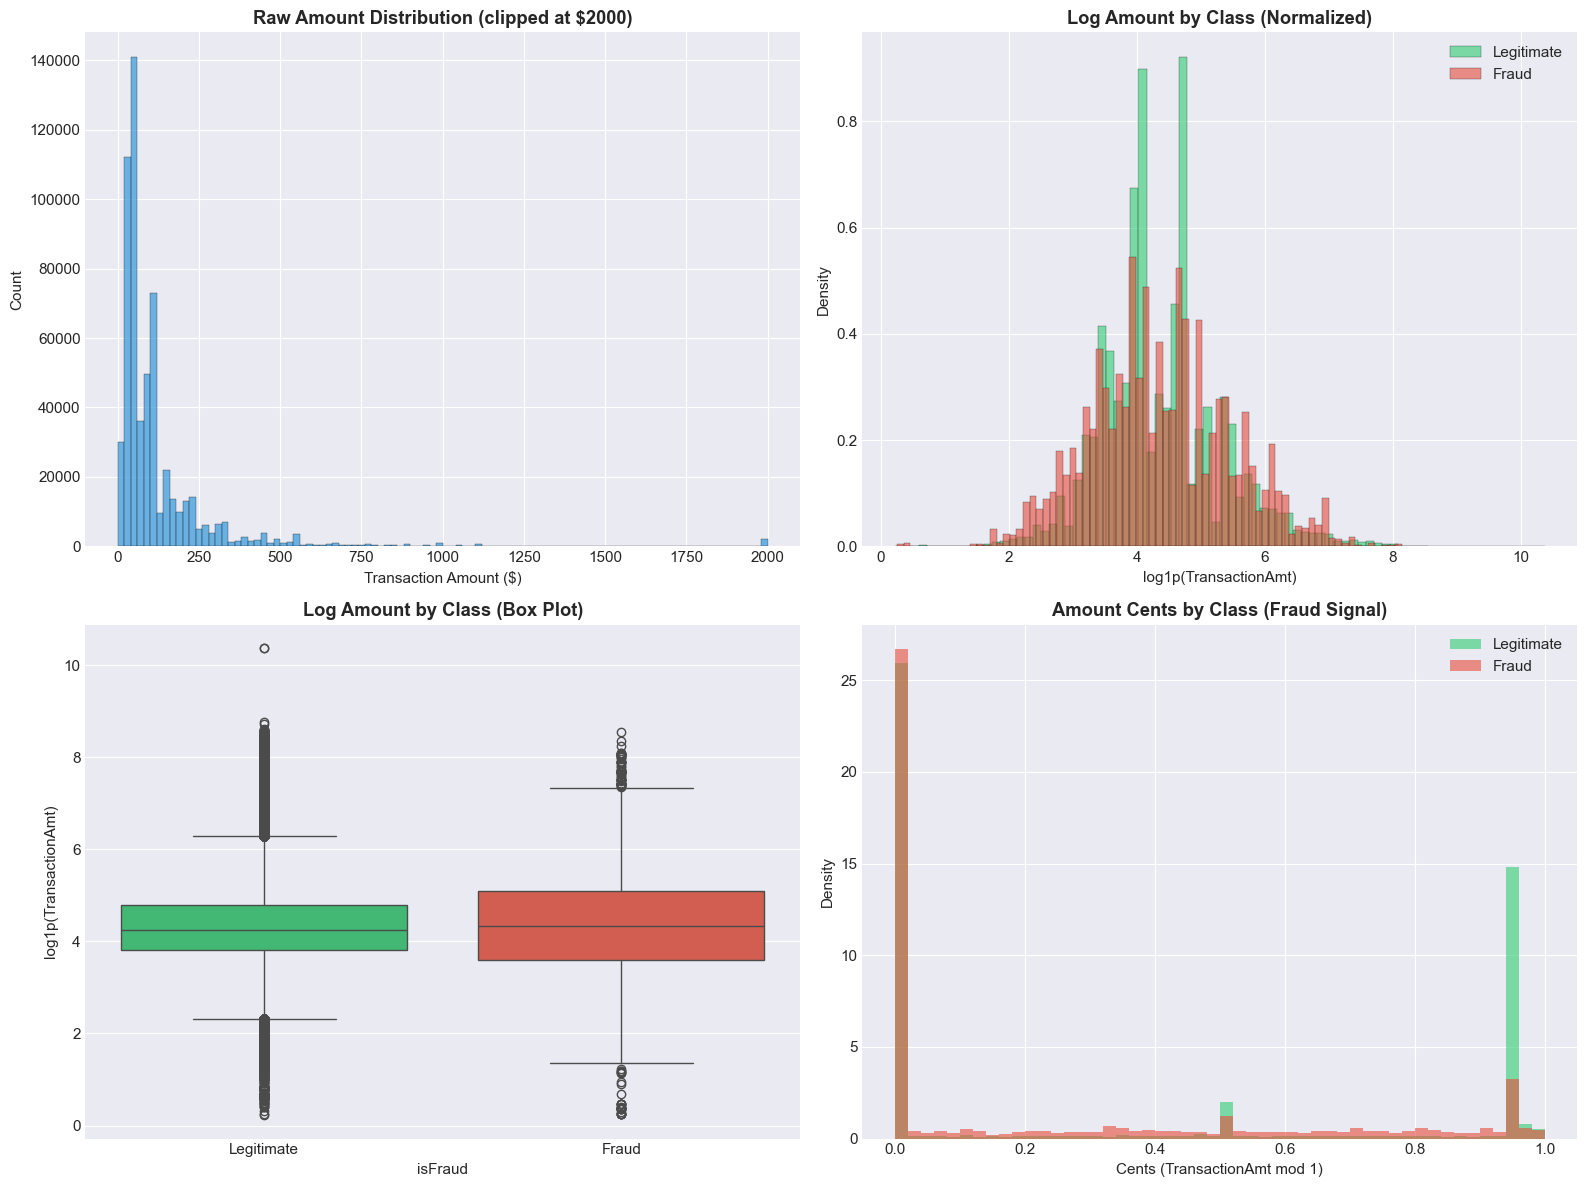


⚠️  Round amounts ($X.00):
   Legitimate: 51.6% are round
   Fraud:      52.7% are round


In [7]:
# Amount statistics by class
print("Transaction Amount Statistics:")
print(df.groupby(TARGET_COL)['TransactionAmt'].describe().T.to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Raw amount distribution (all)
axes[0, 0].hist(df['TransactionAmt'].clip(upper=2000), bins=100, color='#3498db', alpha=0.7, edgecolor='black', linewidth=0.3)
axes[0, 0].set_xlabel('Transaction Amount ($)')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Raw Amount Distribution (clipped at $2000)', fontweight='bold')

# 2. Log-transformed distribution by class
amount_log = np.log1p(df['TransactionAmt'])
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    mask = df[TARGET_COL] == label
    axes[0, 1].hist(amount_log[mask], bins=80, alpha=0.6, color=color, label=name, density=True, edgecolor='black', linewidth=0.3)
axes[0, 1].set_xlabel('log1p(TransactionAmt)')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Log Amount by Class (Normalized)', fontweight='bold')
axes[0, 1].legend()

# 3. Box plot by class
df_plot = df[[TARGET_COL, 'TransactionAmt']].copy()
df_plot['log_amt'] = np.log1p(df_plot['TransactionAmt'])
df_plot[TARGET_COL] = df_plot[TARGET_COL].map({0: 'Legitimate', 1: 'Fraud'})
sns.boxplot(data=df_plot, x=TARGET_COL, y='log_amt', ax=axes[1, 0], palette=colors)
axes[1, 0].set_ylabel('log1p(TransactionAmt)')
axes[1, 0].set_title('Log Amount by Class (Box Plot)', fontweight='bold')

# 4. Amount cents distribution (fraud signal: round amounts)
amount_cents = df['TransactionAmt'] % 1
for label, color, name in [(0, '#2ecc71', 'Legitimate'), (1, '#e74c3c', 'Fraud')]:
    mask = df[TARGET_COL] == label
    axes[1, 1].hist(amount_cents[mask], bins=50, alpha=0.6, color=color, label=name, density=True)
axes[1, 1].set_xlabel('Cents (TransactionAmt mod 1)')
axes[1, 1].set_ylabel('Density')
axes[1, 1].set_title('Amount Cents by Class (Fraud Signal)', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('reports/figures/01_amount_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

# Round amount analysis
is_round = (df['TransactionAmt'] % 1 == 0)
print(f"\n⚠️  Round amounts ($X.00):")
print(f"   Legitimate: {is_round[df[TARGET_COL]==0].mean()*100:.1f}% are round")
print(f"   Fraud:      {is_round[df[TARGET_COL]==1].mean()*100:.1f}% are round")

---
## 5. V-Feature Correlation with Target (PCA Justification)

V1–V339 are masked Vesta engineered features. They are numerous (339 columns), many are highly correlated with each other, and most have moderate-to-low correlation with the target. This justifies PCA reduction to 30 components.

V-features: 339 columns

Top 15 V-features by |correlation| with isFraud:
V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376

Correlation statistics:
  Mean |corr|: 0.0785
  Max  |corr|: 0.3831  (V257)
  Features with |corr| > 0.1: 113
  Features with |corr| < 0.01: 81


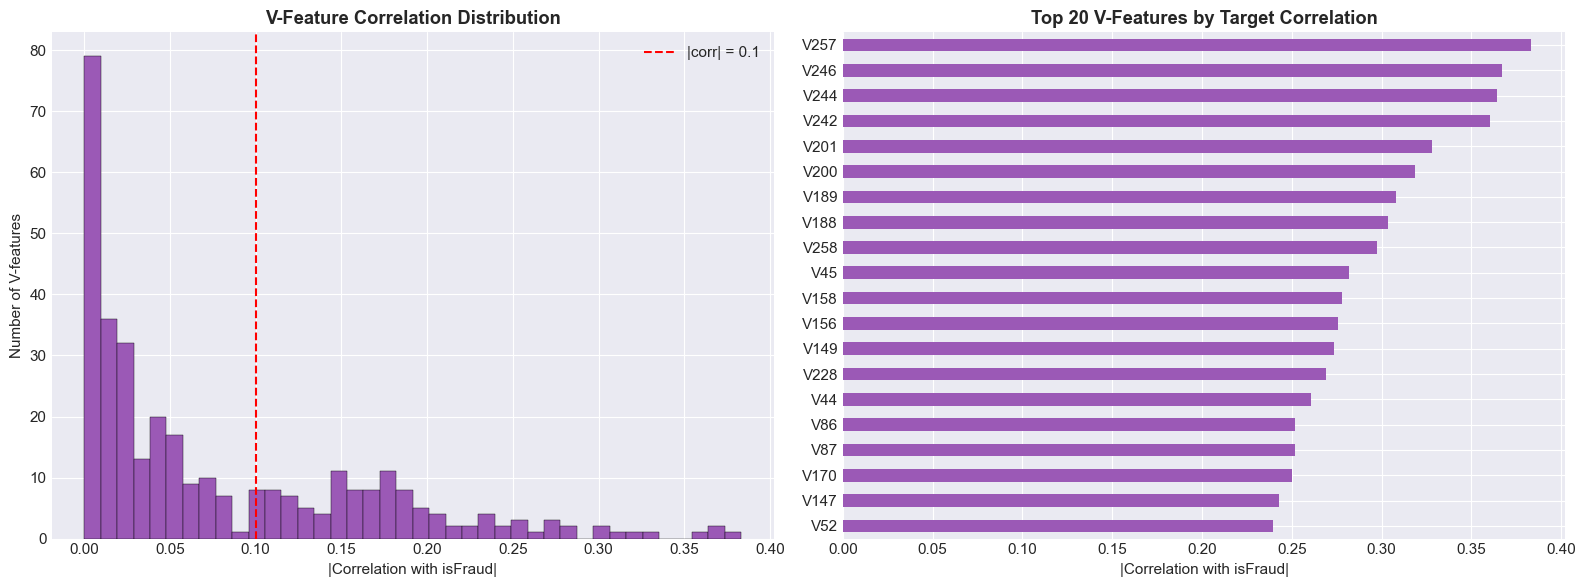

In [8]:
# Correlation of V-features with target
v_cols = [c for c in df.columns if c.startswith('V') and c[1:].isdigit()]
v_target_corr = df[v_cols].corrwith(df[TARGET_COL]).dropna().abs().sort_values(ascending=False)

print(f"V-features: {len(v_cols)} columns")
print(f"\nTop 15 V-features by |correlation| with {TARGET_COL}:")
print(v_target_corr.head(15).to_string())
print(f"\nCorrelation statistics:")
print(f"  Mean |corr|: {v_target_corr.mean():.4f}")
print(f"  Max  |corr|: {v_target_corr.max():.4f}  ({v_target_corr.idxmax()})")
print(f"  Features with |corr| > 0.1: {(v_target_corr > 0.1).sum()}")
print(f"  Features with |corr| < 0.01: {(v_target_corr < 0.01).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of correlations
axes[0].hist(v_target_corr, bins=40, color='#9b59b6', edgecolor='black', linewidth=0.3)
axes[0].axvline(x=0.1, color='red', linestyle='--', label='|corr| = 0.1')
axes[0].set_xlabel('|Correlation with isFraud|')
axes[0].set_ylabel('Number of V-features')
axes[0].set_title('V-Feature Correlation Distribution', fontweight='bold')
axes[0].legend()

# Top 20 V-features
v_target_corr.head(20).plot.barh(ax=axes[1], color='#9b59b6')
axes[1].set_xlabel('|Correlation with isFraud|')
axes[1].set_title('Top 20 V-Features by Target Correlation', fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('reports/figures/01_v_feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()

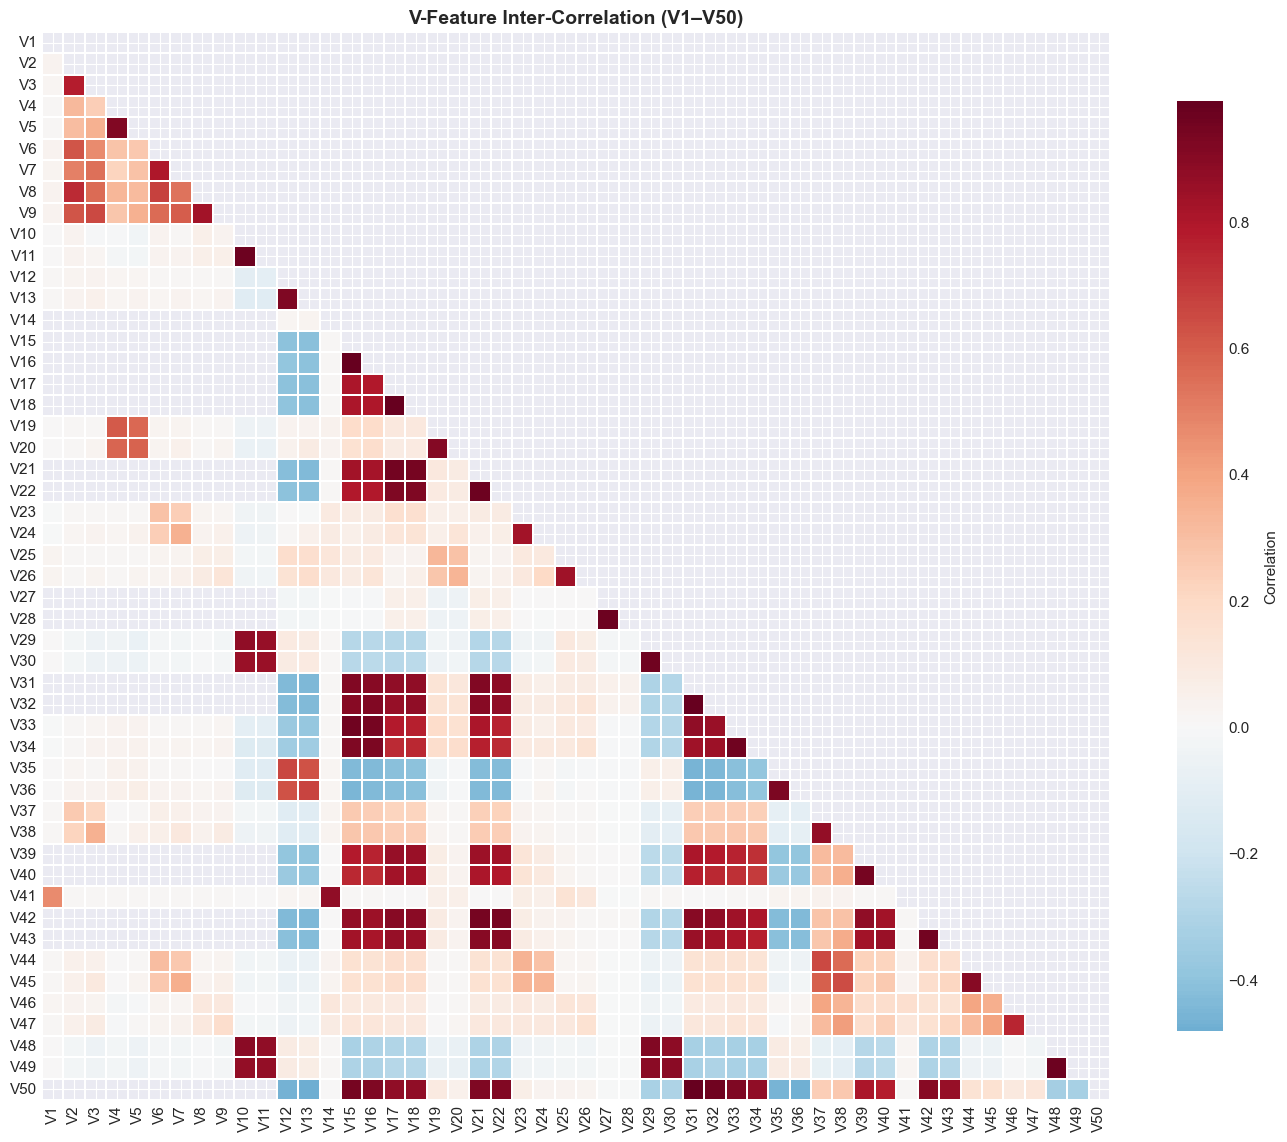


⚠️  V-feature inter-correlation (V1–V50 sample):
   Pairs with |corr| > 0.8: 106 / 1049 (10.1%)
   → High redundancy justifies PCA reduction to 30 components


In [9]:
# Inter-V-feature correlation (sample) — justifies PCA
v_sample = v_cols[:50]  # First 50 V-features for readability
v_corr_matrix = df[v_sample].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(v_corr_matrix, dtype=bool))
sns.heatmap(v_corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.1, ax=ax,
            cbar_kws={'label': 'Correlation', 'shrink': 0.8})
ax.set_title(f'V-Feature Inter-Correlation (V1–V50)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('reports/figures/01_v_feature_intercorrelation.png', bbox_inches='tight', dpi=150)
plt.show()

# Count highly correlated pairs
upper_tri = v_corr_matrix.where(mask == False).stack()
high_corr_pairs = (upper_tri.abs() > 0.8).sum()
total_pairs = len(upper_tri)
print(f"\n⚠️  V-feature inter-correlation (V1–V50 sample):")
print(f"   Pairs with |corr| > 0.8: {high_corr_pairs} / {total_pairs} ({high_corr_pairs/total_pairs*100:.1f}%)")
print(f"   → High redundancy justifies PCA reduction to {config['features']['v_features_pca_components']} components")

---
## 5b. PCA Variance Retained (Computed, Train-Only Fit)

The correlation analysis above justifies *why* PCA is applied; this section
computes the actual variance retained. To be a fair estimate of what
production sees, the components are fitted on **train rows only** — using
the same `time_based_split_3way` split and `FeatureEngineer.reduce_v_features`
that `src/data/preprocess.py` uses post-Phase-A — not on the full dataset.


In [10]:
# Fit PCA the same way production does: components estimated from train
# rows only (time-based split), matching src/data/preprocess.py after the
# Phase A leakage fix. This replaces the notebook's former uncomputed
# ">85% variance" assertion with a real number (docs/IMPLEMENTATION_PLAN.md D8).
import gc

from src.data.data_splitter import time_based_split_3way
from src.data.feature_engineering import FeatureEngineer

split_projection = df[[TEMPORAL_COL, TARGET_COL]].copy()
split_projection["_row_id"] = np.arange(len(split_projection), dtype=np.int64)

X_train_proj, X_val_proj, X_test_proj, _, _, _ = time_based_split_3way(
    df=split_projection,
    temporal_col=TEMPORAL_COL,
    train_ratio=config["data"]["train_split_ratio"],
    val_ratio=config["data"]["val_split_ratio"],
)

train_mask = np.zeros(len(df), dtype=bool)
train_mask[X_train_proj["_row_id"].to_numpy()] = True
print(f"Train rows for PCA fit: {train_mask.sum():,} / {len(df):,} ({train_mask.mean() * 100:.1f}%)")
del split_projection, X_train_proj, X_val_proj, X_test_proj

n_pca = config["features"]["v_features_pca_components"]
fe_eda = FeatureEngineer()
df_pca_check = fe_eda.reduce_v_features(df, fit=True, n_components=n_pca, fit_rows=train_mask)
variance_retained = fe_eda._pca.explained_variance_ratio_.sum()

print(f"\nPCA fit (train-only, matches src/data/preprocess.py):")
print(f"  {len(v_cols)} V-features -> {n_pca} components")
print(f"  Variance retained: {variance_retained:.1%}")

del df_pca_check
gc.collect()


Train rows for PCA fit: 413,378 / 590,540 (70.0%)



PCA fit (train-only, matches src/data/preprocess.py):
  339 V-features -> 30 components
  Variance retained: 100.0%


0

---
## 6. Temporal Distribution: Fraud Rate by Hour & Day of Week

`TransactionDT` is seconds since a reference point (not Unix time). We extract hour-of-day and day-of-week to check for temporal fraud patterns.

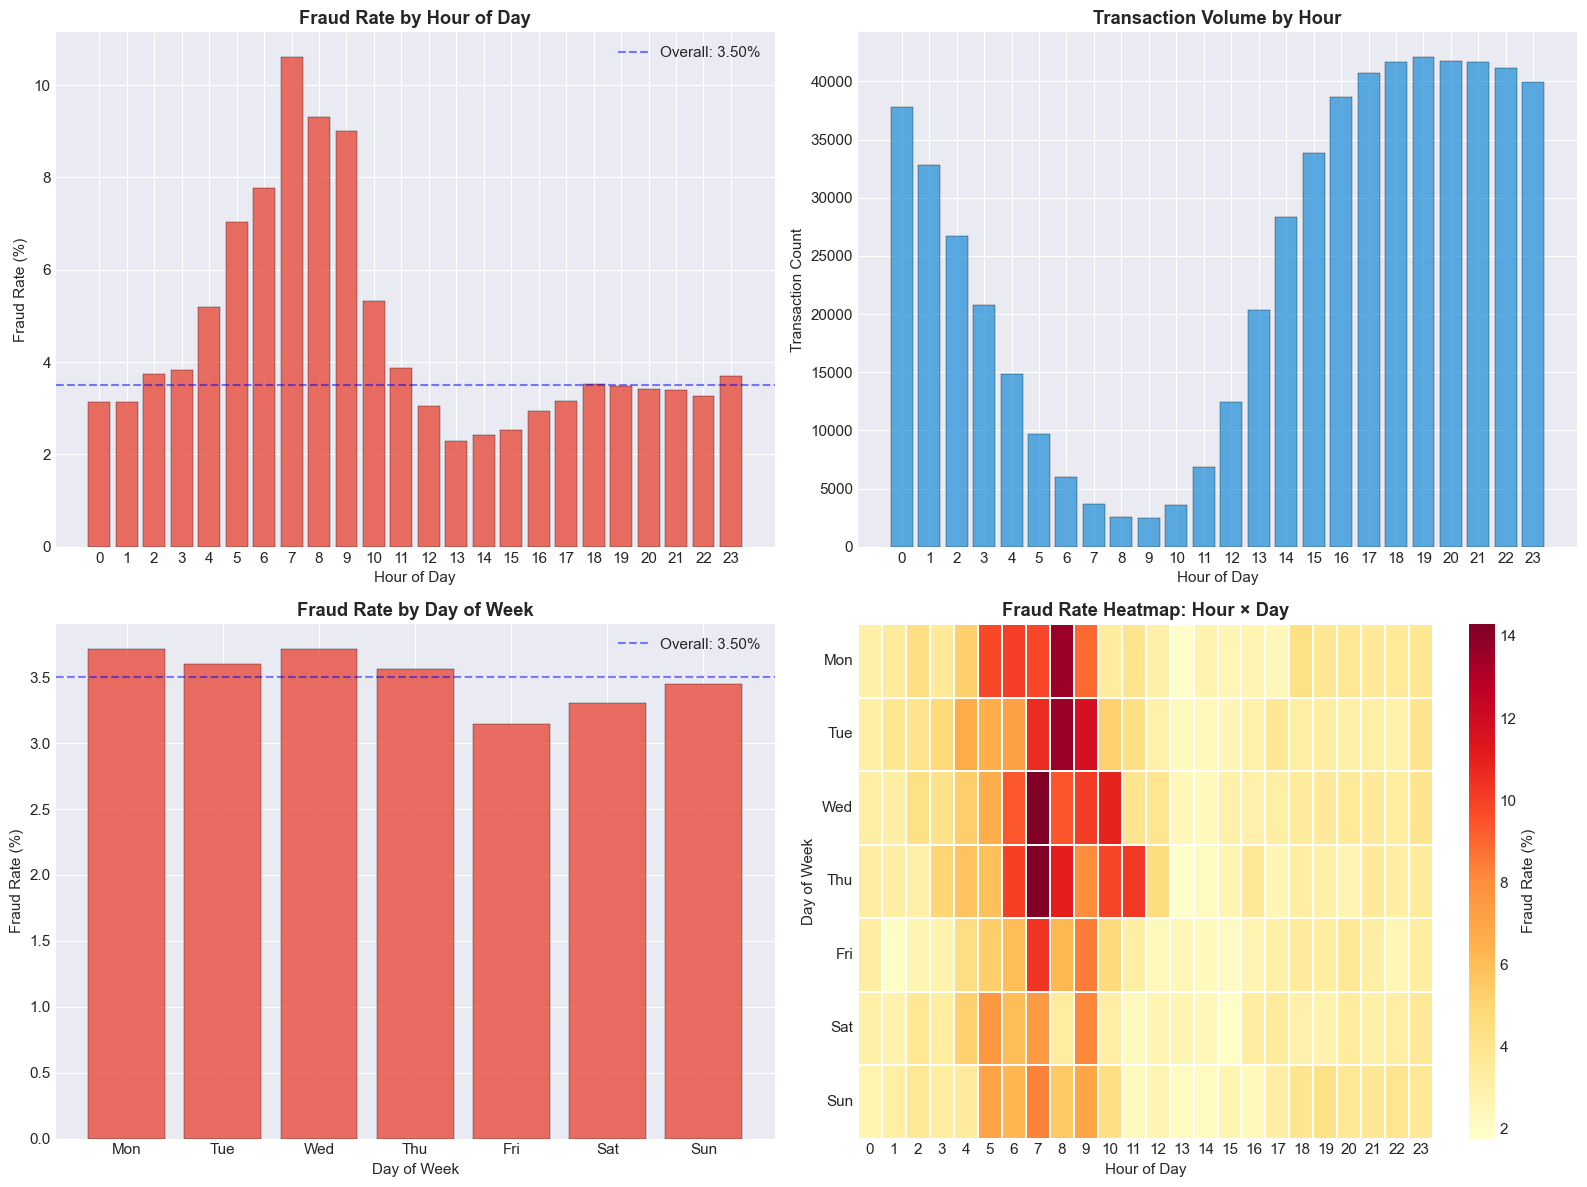


⚠️  Temporal fraud patterns:
   Peak fraud hour:   7:00 (10.61%)
   Lowest fraud hour: 13:00 (2.29%)
   → Cyclical sin/cos encoding preserves hour 23 ↔ hour 0 adjacency


In [11]:
# Extract temporal features
seconds_in_day = 86400
df['hour_of_day'] = (df[TEMPORAL_COL] % seconds_in_day // 3600).astype(int)
df['day_of_week'] = (df[TEMPORAL_COL] // seconds_in_day % 7).astype(int)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Fraud rate by hour of day
hourly_fraud = df.groupby('hour_of_day')[TARGET_COL].agg(['mean', 'count'])
hourly_fraud.columns = ['fraud_rate', 'tx_count']
hourly_fraud['fraud_rate'] *= 100

ax1 = axes[0, 0]
bars = ax1.bar(hourly_fraud.index, hourly_fraud['fraud_rate'], color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Fraud Rate (%)')
ax1.set_title('Fraud Rate by Hour of Day', fontweight='bold')
ax1.axhline(y=fraud_rate, color='blue', linestyle='--', alpha=0.5, label=f'Overall: {fraud_rate:.2f}%')
ax1.legend()
ax1.set_xticks(range(24))

# 2. Transaction volume by hour
ax2 = axes[0, 1]
ax2.bar(hourly_fraud.index, hourly_fraud['tx_count'], color='#3498db', alpha=0.8, edgecolor='black', linewidth=0.3)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Transaction Count')
ax2.set_title('Transaction Volume by Hour', fontweight='bold')
ax2.set_xticks(range(24))

# 3. Fraud rate by day of week
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
daily_fraud = df.groupby('day_of_week')[TARGET_COL].agg(['mean', 'count'])
daily_fraud.columns = ['fraud_rate', 'tx_count']
daily_fraud['fraud_rate'] *= 100

ax3 = axes[1, 0]
ax3.bar(daily_fraud.index, daily_fraud['fraud_rate'], color='#e74c3c', alpha=0.8, edgecolor='black', linewidth=0.3)
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Fraud Rate (%)')
ax3.set_title('Fraud Rate by Day of Week', fontweight='bold')
ax3.set_xticks(range(7))
ax3.set_xticklabels(day_names)
ax3.axhline(y=fraud_rate, color='blue', linestyle='--', alpha=0.5, label=f'Overall: {fraud_rate:.2f}%')
ax3.legend()

# 4. Fraud rate heatmap: hour × day
heatmap_data = df.groupby(['day_of_week', 'hour_of_day'])[TARGET_COL].mean().unstack() * 100
ax4 = axes[1, 1]
sns.heatmap(heatmap_data, cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Fraud Rate (%)'}, linewidths=0.1)
ax4.set_xlabel('Hour of Day')
ax4.set_ylabel('Day of Week')
ax4.set_yticklabels(day_names, rotation=0)
ax4.set_title('Fraud Rate Heatmap: Hour × Day', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/01_temporal_distribution.png', bbox_inches='tight', dpi=150)
plt.show()

peak_hour = hourly_fraud['fraud_rate'].idxmax()
peak_rate = hourly_fraud['fraud_rate'].max()
trough_hour = hourly_fraud['fraud_rate'].idxmin()
trough_rate = hourly_fraud['fraud_rate'].min()
print(f"\n⚠️  Temporal fraud patterns:")
print(f"   Peak fraud hour:   {peak_hour}:00 ({peak_rate:.2f}%)")
print(f"   Lowest fraud hour: {trough_hour}:00 ({trough_rate:.2f}%)")
print(f"   → Cyclical sin/cos encoding preserves hour 23 ↔ hour 0 adjacency")

---
## 7. Card-Level Aggregation: Transaction Count & Amount Distributions

`card1` is a proxy for card number. Analyzing per-card transaction patterns reveals velocity features that are strong fraud signals.

Unique cards (card1): 13,553

Card transaction count distribution:
count    13553.000000
mean        43.572641
std        329.084462
min          1.000000
25%          1.000000
50%          4.000000
75%         14.000000
max      14932.000000


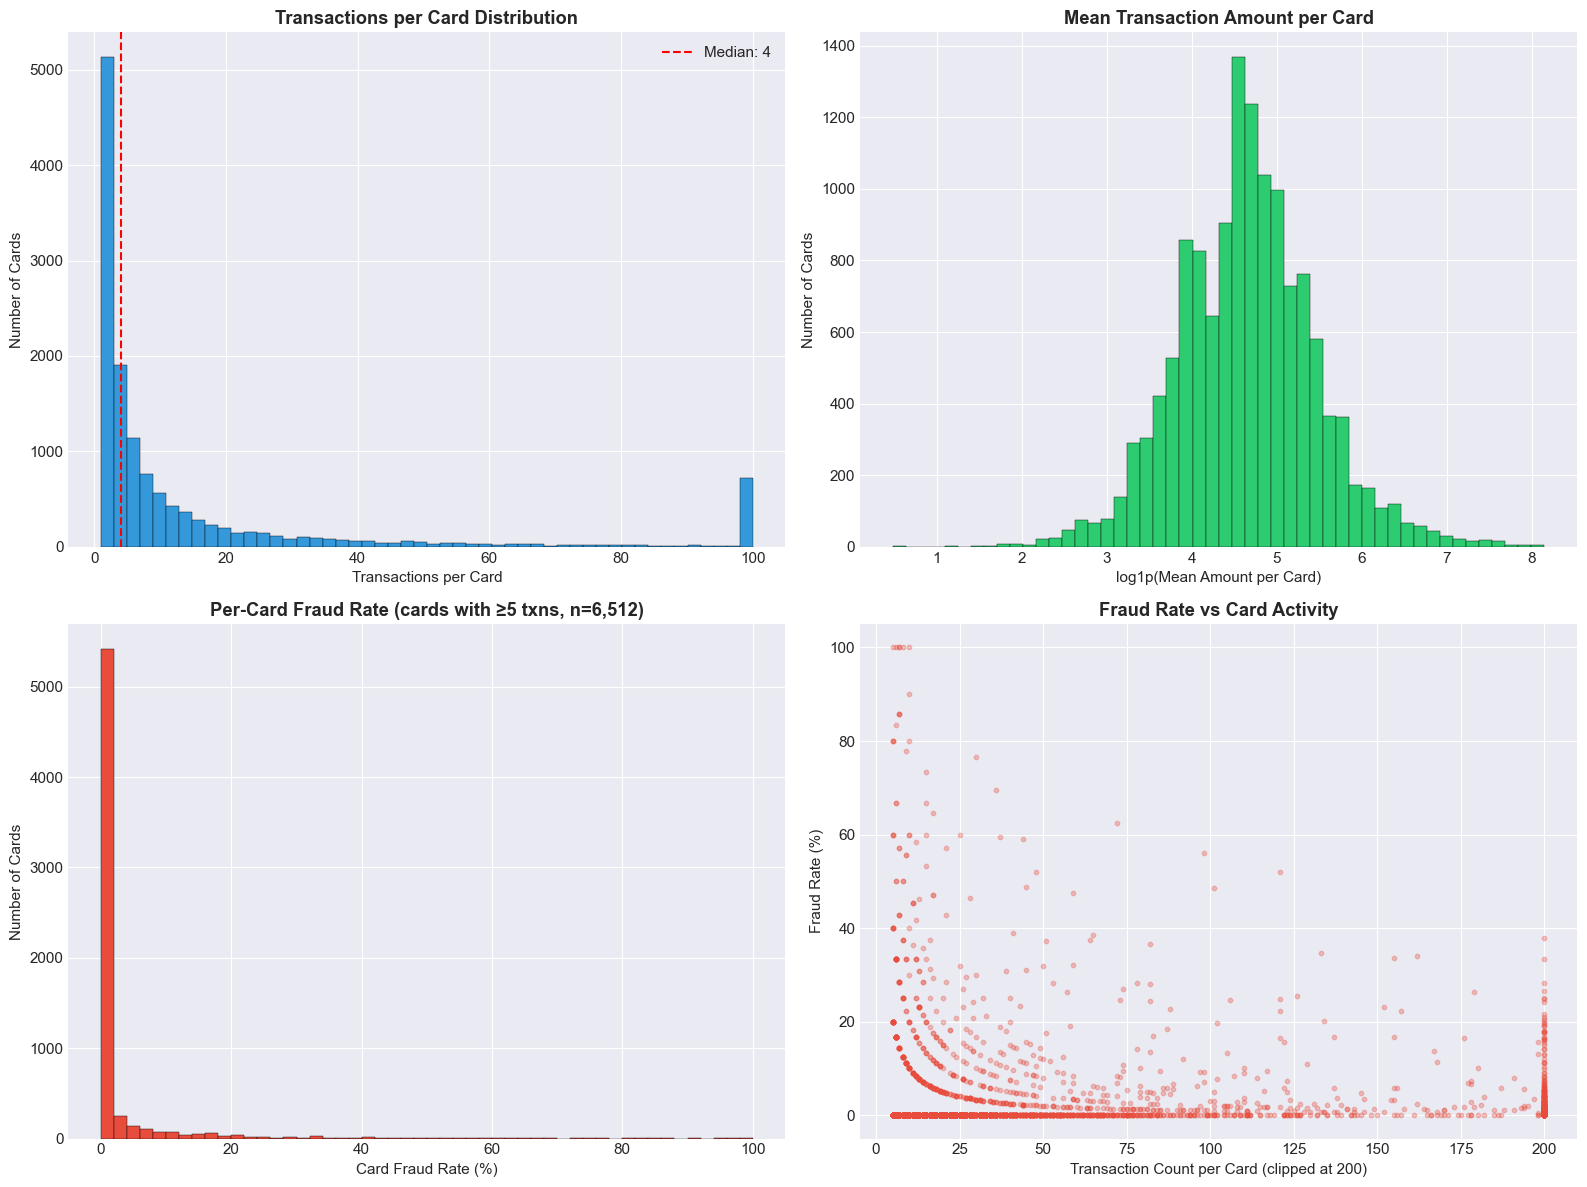


⚠️  Card-level features justify the card aggregate features in feature_engineering.py:
   tx_count_per_card, mean_amount_per_card, max_amount_per_card,
   std_amount_per_card, amount_vs_mean_ratio


In [12]:
# Card-level aggregation
card_stats = df.groupby('card1').agg(
    tx_count=('TransactionAmt', 'count'),
    mean_amount=('TransactionAmt', 'mean'),
    max_amount=('TransactionAmt', 'max'),
    std_amount=('TransactionAmt', 'std'),
    fraud_rate=(TARGET_COL, 'mean'),
).reset_index()

print(f"Unique cards (card1): {card_stats.shape[0]:,}")
print(f"\nCard transaction count distribution:")
print(card_stats['tx_count'].describe().to_string())

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Transaction count per card
axes[0, 0].hist(card_stats['tx_count'].clip(upper=100), bins=50, color='#3498db', edgecolor='black', linewidth=0.3)
axes[0, 0].set_xlabel('Transactions per Card')
axes[0, 0].set_ylabel('Number of Cards')
axes[0, 0].set_title('Transactions per Card Distribution', fontweight='bold')
axes[0, 0].axvline(x=card_stats['tx_count'].median(), color='red', linestyle='--',
                    label=f"Median: {card_stats['tx_count'].median():.0f}")
axes[0, 0].legend()

# 2. Mean amount per card
axes[0, 1].hist(np.log1p(card_stats['mean_amount']), bins=50, color='#2ecc71', edgecolor='black', linewidth=0.3)
axes[0, 1].set_xlabel('log1p(Mean Amount per Card)')
axes[0, 1].set_ylabel('Number of Cards')
axes[0, 1].set_title('Mean Transaction Amount per Card', fontweight='bold')

# 3. Per-card fraud rate distribution (only cards with enough transactions)
cards_enough = card_stats[card_stats['tx_count'] >= 5]
axes[1, 0].hist(cards_enough['fraud_rate'] * 100, bins=50, color='#e74c3c', edgecolor='black', linewidth=0.3)
axes[1, 0].set_xlabel('Card Fraud Rate (%)')
axes[1, 0].set_ylabel('Number of Cards')
axes[1, 0].set_title(f'Per-Card Fraud Rate (cards with ≥5 txns, n={len(cards_enough):,})', fontweight='bold')

# 4. Fraud rate vs transaction count (scatter)
sample = cards_enough.sample(min(5000, len(cards_enough)), random_state=42)
axes[1, 1].scatter(sample['tx_count'].clip(upper=200), sample['fraud_rate'] * 100,
                   alpha=0.3, s=10, c='#e74c3c')
axes[1, 1].set_xlabel('Transaction Count per Card (clipped at 200)')
axes[1, 1].set_ylabel('Fraud Rate (%)')
axes[1, 1].set_title('Fraud Rate vs Card Activity', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/01_card_aggregation.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n⚠️  Card-level features justify the card aggregate features in feature_engineering.py:")
print(f"   tx_count_per_card, mean_amount_per_card, max_amount_per_card,")
print(f"   std_amount_per_card, amount_vs_mean_ratio")

---
## 8. Fraud Rate by ProductCD — Key Feature Signal

ProductCD is a categorical feature with values: W, H, C, S, R.
This is one of the **strongest fraud signals** in the IEEE-CIS dataset.

ProductCD Analysis:
           tx_count  fraud_count  fraud_rate_pct  tx_share_pct  mean_amount
ProductCD                                                                  
W            439670         8969        2.039939     74.452196   153.158554
C             68519         8008       11.687269     11.602770    42.872353
R             37699         1426        3.782594      6.383818   168.306188
H             33024         1574        4.766231      5.592170    73.170058
S             11628          686        5.899553      1.969045    60.269487


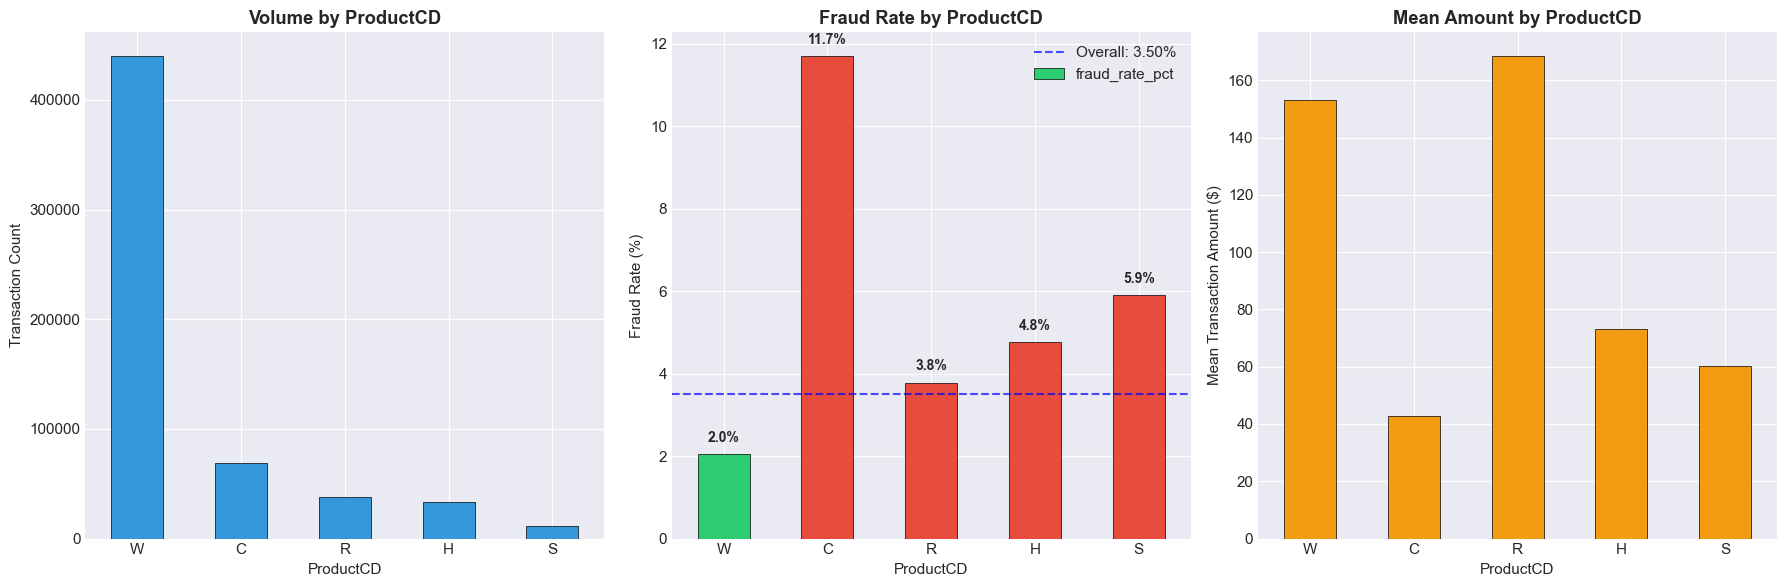


⚠️  KEY INSIGHT: ProductCD 'C' has the highest fraud rate (11.7%)
   ProductCD 'W' dominates volume but has the lowest fraud rate.
   → ProductCD is a very strong categorical signal for fraud detection.


In [13]:
# Fraud rate by ProductCD
product_stats = df.groupby('ProductCD').agg(
    tx_count=('TransactionAmt', 'count'),
    fraud_count=(TARGET_COL, 'sum'),
    fraud_rate=(TARGET_COL, 'mean'),
    mean_amount=('TransactionAmt', 'mean'),
).sort_values('tx_count', ascending=False)
product_stats['fraud_rate_pct'] = product_stats['fraud_rate'] * 100
product_stats['tx_share_pct'] = product_stats['tx_count'] / product_stats['tx_count'].sum() * 100

print("ProductCD Analysis:")
print(product_stats[['tx_count', 'fraud_count', 'fraud_rate_pct', 'tx_share_pct', 'mean_amount']].to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Transaction count by ProductCD
product_stats['tx_count'].plot.bar(ax=axes[0], color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_xlabel('ProductCD')
axes[0].set_ylabel('Transaction Count')
axes[0].set_title('Volume by ProductCD', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)

# 2. Fraud rate by ProductCD
bar_colors = ['#e74c3c' if rate > fraud_rate else '#2ecc71'
              for rate in product_stats['fraud_rate_pct']]
product_stats['fraud_rate_pct'].plot.bar(ax=axes[1], color=bar_colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(y=fraud_rate, color='blue', linestyle='--', alpha=0.7, label=f'Overall: {fraud_rate:.2f}%')
axes[1].set_xlabel('ProductCD')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by ProductCD', fontweight='bold')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)
for i, (idx, row) in enumerate(product_stats.iterrows()):
    axes[1].text(i, row['fraud_rate_pct'] + 0.3, f"{row['fraud_rate_pct']:.1f}%",
                ha='center', fontweight='bold', fontsize=10)

# 3. Mean amount by ProductCD
product_stats['mean_amount'].plot.bar(ax=axes[2], color='#f39c12', edgecolor='black', linewidth=0.5)
axes[2].set_xlabel('ProductCD')
axes[2].set_ylabel('Mean Transaction Amount ($)')
axes[2].set_title('Mean Amount by ProductCD', fontweight='bold')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/01_product_cd_fraud_rate.png', bbox_inches='tight', dpi=150)
plt.show()

highest_fraud_product = product_stats['fraud_rate_pct'].idxmax()
highest_fraud_rate = product_stats['fraud_rate_pct'].max()
print(f"\n⚠️  KEY INSIGHT: ProductCD '{highest_fraud_product}' has the highest fraud rate ({highest_fraud_rate:.1f}%)")
print(f"   ProductCD 'W' dominates volume but has the lowest fraud rate.")
print(f"   → ProductCD is a very strong categorical signal for fraud detection.")

---
## 9. Additional Feature Exploration

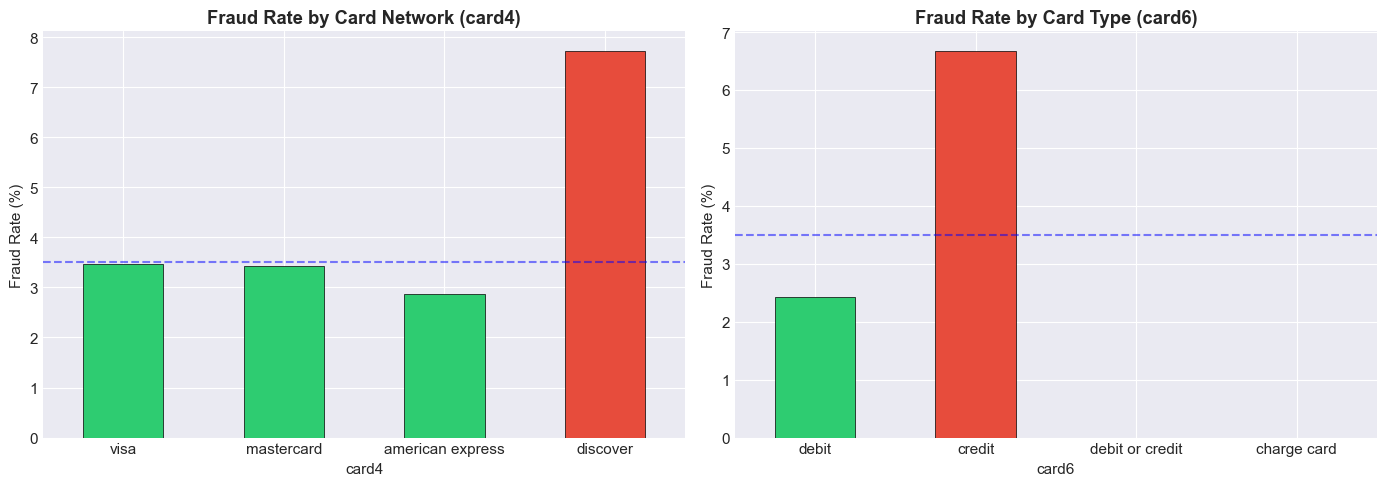

In [14]:
# Card type analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# card4: payment network
for ax, col, title in [(axes[0], 'card4', 'Card Network'), (axes[1], 'card6', 'Card Type')]:
    if col not in df.columns:
        continue
    cat_fraud = df.groupby(col)[TARGET_COL].agg(['mean', 'count']).sort_values('count', ascending=False)
    cat_fraud['mean'] *= 100
    bar_colors = ['#e74c3c' if r > fraud_rate else '#2ecc71' for r in cat_fraud['mean']]
    cat_fraud['mean'].plot.bar(ax=ax, color=bar_colors, edgecolor='black', linewidth=0.5)
    ax.axhline(y=fraud_rate, color='blue', linestyle='--', alpha=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Fraud Rate (%)')
    ax.set_title(f'Fraud Rate by {title} ({col})', fontweight='bold')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('reports/figures/01_card_type_fraud.png', bbox_inches='tight', dpi=150)
plt.show()

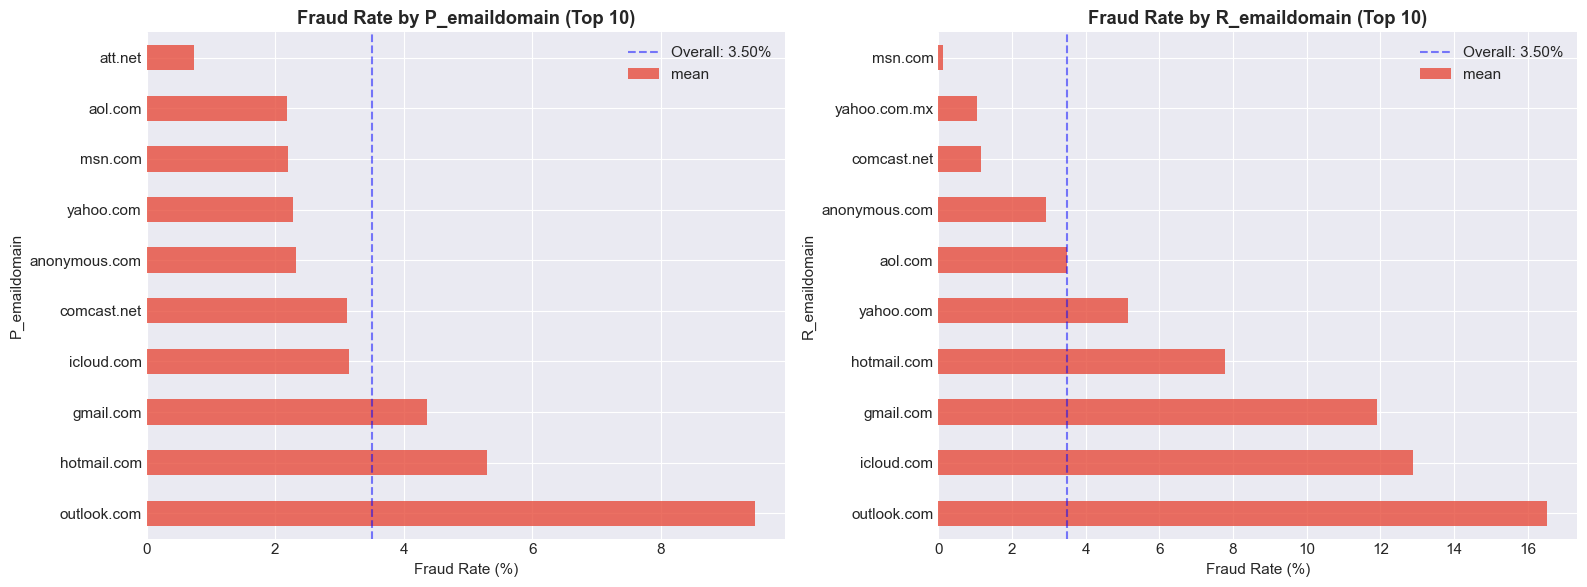

In [15]:
# Email domain analysis
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col in [(axes[0], 'P_emaildomain'), (axes[1], 'R_emaildomain')]:
    if col not in df.columns:
        continue
    top_domains = df[col].value_counts().head(10).index
    subset = df[df[col].isin(top_domains)]
    domain_fraud = subset.groupby(col)[TARGET_COL].agg(['mean', 'count']).sort_values('mean', ascending=False)
    domain_fraud['mean'] *= 100
    domain_fraud['mean'].plot.barh(ax=ax, color='#e74c3c', alpha=0.8)
    ax.axvline(x=fraud_rate, color='blue', linestyle='--', alpha=0.5, label=f'Overall: {fraud_rate:.2f}%')
    ax.set_xlabel('Fraud Rate (%)')
    ax.set_title(f'Fraud Rate by {col} (Top 10)', fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.savefig('reports/figures/01_email_domain_fraud.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 10. Summary of Key Findings

| Finding | Impact on Pipeline |
|---------|-------------------|
| **3.50% fraud rate** | Use PR-AUC as primary metric. Apply SMOTE / class weighting / Focal Loss. |
| **75.6% NaN from identity join** | Fill numerical with -999 sentinel, categorical with 'MISSING'. |
| **339 V-features, high inter-correlation (10.1% of V1–V50 pairs \|corr\| > 0.8)** | PCA to 30 components, fitted on train rows only, retains **100.0%** of variance (§5b) — reduces dimensionality at no measured cost. |
| **ProductCD is strong signal** | C (11.7%) has the highest fraud rate; W dominates volume (74.5%) but has the lowest rate (2.0%). |
| **Temporal patterns in fraud** | Peak fraud at hour 7:00 (10.6%), lowest at hour 13:00 (2.3%); sin/cos encoding preserves cyclicity. |
| **Card-level velocity matters** | tx_count, mean_amount, amount_vs_mean_ratio are strong features. |
| **Round amounts correlate with fraud** | 52.7% of fraud amounts are round vs. 51.6% of legitimate — amount_cents feature captures this signal. |
| **Time-based split required** | TransactionDT ordering prevents leakage from future patterns. |

### Next Steps
- Run `python src/data/preprocess.py` to execute the full feature engineering pipeline
- All findings above are coded into `src/data/feature_engineering.py`
- Proceed to Phase 2: XGBoost baseline model training


In [16]:
# Clean up temporary columns
df.drop(columns=['hour_of_day', 'day_of_week'], inplace=True, errors='ignore')

print("\n" + "=" * 60)
print("EDA COMPLETE")
print("=" * 60)
print(f"Figures saved to: reports/figures/")
print(f"Proceed to Phase 2 with preprocessed data from: data/processed/")


EDA COMPLETE
Figures saved to: reports/figures/
Proceed to Phase 2 with preprocessed data from: data/processed/
